<a href="https://colab.research.google.com/github/nancy-shehata/healthy_hrv_model/blob/main/LSTM_W_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL A — Load all 54 subjects in ms, save per-subject stats
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

rr_root = "/content/drive/MyDrive/ALS Heart Rate Data/NSR Processed/RR Intervals"

def load_rr_file(file_path):
    signal = np.loadtxt(file_path)
    signal = np.asarray(signal, dtype=np.float32)
    signal = signal[~np.isnan(signal)]
    # artifact filter: keep only physiologically valid beats (300-2000ms)
    signal = signal[(signal >= 300) & (signal <= 2000)]
    return signal

# Check if the directory exists before attempting to list its contents
if not os.path.exists(rr_root):
    print(f"Error: The directory '{rr_root}' was not found. Please ensure Google Drive is mounted and the path is correct.")
    rr_signals = {}
    subject_stats = {}
else:
    # Load all 54 subjects — keep in ms
    rr_signals = {}
    for file_name in sorted(os.listdir(rr_root)):
        if file_name.endswith(".txt"):
            full_path = os.path.join(rr_root, file_name)
            rr_signals[file_name] = load_rr_file(full_path)

    print(f"Loaded {len(rr_signals)} subjects")

    # Save per-subject mean and std in ms — needed for denormalization later
    subject_stats = {}
    for name, sig in rr_signals.items():
        subject_stats[name] = {
            "mean": float(np.mean(sig)),
            "std":  float(np.std(sig)) if np.std(sig) > 0 else 1.0
        }

    if rr_signals:
        print("Sample stats (first subject):")
        first = list(subject_stats.values())[0]
        print(f"  mean RR: {first['mean']:.1f} ms,  std: {first['std']:.1f} ms")
    else:
        print("No RR signals loaded to compute sample stats.")


Mounted at /content/drive
Loaded 54 subjects
Sample stats (first subject):
  mean RR: 759.2 ms,  std: 169.7 ms


In [ ]:
# ============================================================
# CELL B — Helper functions (sequences, model builder, HRV metrics)
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEQ_LENGTH = 20
STEP_SIZE  = 10
GEN_LENGTH = 1000   # beats to generate per subject

def create_sequences(signal_norm, seq_length=SEQ_LENGTH, step_size=STEP_SIZE):
    """Sliding window: X = seq_length beats, y = next beat (normalized)."""
    X, y = [], []
    if len(signal_norm) <= seq_length:
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
    for i in range(0, len(signal_norm) - seq_length, step_size):
        X.append(signal_norm[i : i + seq_length])
        y.append(signal_norm[i + seq_length])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def build_model(seq_length=SEQ_LENGTH):
    """Same architecture as original notebook."""
    model = Sequential([
        LSTM(64, input_shape=(seq_length, 1), return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

def compute_hrv_metrics(rr_ms):
    """Compute SDNN, RMSSD, mean RR, SD1, SD2 from an RR sequence in ms."""
    rr = np.array(rr_ms, dtype=np.float64)
    mean_rr = np.mean(rr)
    sdnn    = np.std(rr, ddof=1)
    diff    = np.diff(rr)
    rmssd   = np.sqrt(np.mean(diff ** 2))
    # Poincare
    sd1 = np.std(diff, ddof=1) / np.sqrt(2)
    sd2 = np.sqrt(2 * sdnn**2 - sd1**2)
    return {"mean_rr": mean_rr, "sdnn": sdnn, "rmssd": rmssd, "sd1": sd1, "sd2": sd2}

def generate_sequence(model, seed_beats_norm, gen_length, mean_ms, std_ms, noise_std=0.15):
    """
    Autoregressively generate gen_length beats in ms.
    noise_std: std of Gaussian noise injected at each step (in normalized units)
               0.05 ≈ 5% of 1 std dev — small enough not to distort,
               large enough to break mean collapse
    """
    buffer = list(seed_beats_norm[-SEQ_LENGTH:])
    generated_norm = []

    for _ in range(gen_length):
        x_in = np.array(buffer[-SEQ_LENGTH:], dtype=np.float32).reshape(1, SEQ_LENGTH, 1)
        next_beat_norm = model.predict(x_in, verbose=0)[0, 0]

        # inject small noise before feeding back in
        next_beat_norm += np.random.normal(0, noise_std)

        generated_norm.append(next_beat_norm)
        buffer.append(next_beat_norm)

    generated_ms = np.array(generated_norm) * std_ms + mean_ms
    return generated_ms

    # try hypertuning the model and change 1 parameter at a time to understand the impact it has on the result
    # try nested cross validation only for hyperparameter tuning. take the best and for the hyper
    # finding the best hyper parameters ^

    # K fold validation. k is number of split, the benefit is you don't have
    # amarel (super computer)


In [ ]:
import os

CHECKPOINT_PATH = "/content/drive/MyDrive/ALS Heart Rate Data/lstm_loocv_results.csv"

if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print("Checkpoint deleted — will rerun from fold 1")
else:
    print("No checkpoint found")

No checkpoint found


In [ ]:
# ============================================================
# CELL C — LOOCV: 54 folds, train on 53, generate + evaluate held-out
# ============================================================

import pandas as pd
from sklearn.model_selection import train_test_split

CHECKPOINT_PATH = "/content/drive/MyDrive/ALS Heart Rate Data/lstm_loocv_results.csv"
EPOCHS     = 20
BATCH_SIZE = 128

subject_names = sorted(rr_signals.keys())
n_subjects    = len(subject_names)

# Resume from checkpoint if it exists
if os.path.exists(CHECKPOINT_PATH):
    results_df    = pd.read_csv(CHECKPOINT_PATH)
    completed     = set(results_df["subject"].tolist())
    print(f"Resuming — {len(completed)}/{n_subjects} folds already done")
else:
    results_df = pd.DataFrame()
    completed  = set()

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

for fold_idx, held_out_name in enumerate(subject_names):

    if held_out_name in completed:
        print(f"Fold {fold_idx+1}/{n_subjects} [{held_out_name}] — skipped (already done)")
        continue

    print(f"\nFold {fold_idx+1}/{n_subjects} — held out: {held_out_name}")

    # --- Build training set from 53 subjects ---
    X_train_all, y_train_all = [], []
    for name, sig in rr_signals.items():
        if name == held_out_name:
            continue
        stats = subject_stats[name]
        sig_norm = (sig - stats["mean"]) / stats["std"]
        X_seq, y_seq = create_sequences(sig_norm)
        X_train_all.append(X_seq)
        y_train_all.append(y_seq)

    X_train_all = np.concatenate(X_train_all, axis=0)
    y_train_all = np.concatenate(y_train_all, axis=0)

    # Reshape for LSTM
    X_train_all = X_train_all.reshape(-1, SEQ_LENGTH, 1)

    # Internal val split for early stopping
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_all, y_train_all, test_size=0.1, random_state=42
    )

    # --- Train ---
    model = build_model()
    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    # --- Generate for held-out subject ---
    held_sig   = rr_signals[held_out_name]
    held_mean  = subject_stats[held_out_name]["mean"]
    held_std   = subject_stats[held_out_name]["std"]
    held_norm  = (held_sig - held_mean) / held_std

    seed = held_norm[:SEQ_LENGTH]   # first 20 real beats as seed
    synthetic_ms = generate_sequence(model, seed, GEN_LENGTH, held_mean, held_std)

    # Real reference: first GEN_LENGTH beats of held-out subject (in ms)
    real_ms = held_sig[:GEN_LENGTH]
    min_len = min(len(real_ms), len(synthetic_ms))
    real_ms      = real_ms[:min_len]
    synthetic_ms = synthetic_ms[:min_len]

    # --- Compute metrics ---
    rmse = float(np.sqrt(np.mean((real_ms - synthetic_ms) ** 2)))

    real_hrv = compute_hrv_metrics(real_ms)
    syn_hrv  = compute_hrv_metrics(synthetic_ms)

    fold_result = {
        "subject":       held_out_name,
        "rmse_ms":       rmse,
        # real HRV
        "real_mean_rr":  real_hrv["mean_rr"],
        "real_sdnn":     real_hrv["sdnn"],
        "real_rmssd":    real_hrv["rmssd"],
        "real_sd1":      real_hrv["sd1"],
        "real_sd2":      real_hrv["sd2"],
        # synthetic HRV
        "syn_mean_rr":   syn_hrv["mean_rr"],
        "syn_sdnn":      syn_hrv["sdnn"],
        "syn_rmssd":     syn_hrv["rmssd"],
        "syn_sd1":       syn_hrv["sd1"],
        "syn_sd2":       syn_hrv["sd2"],
    }

    # Append and checkpoint
    results_df = pd.concat([results_df, pd.DataFrame([fold_result])], ignore_index=True)
    results_df.to_csv(CHECKPOINT_PATH, index=False)
    print(f"  RMSE: {rmse:.2f} ms | real SDNN: {real_hrv['sdnn']:.2f} | syn SDNN: {syn_hrv['sdnn']:.2f}")

print("\nLOOCV complete.")


Resuming — 44/54 folds already done
Fold 1/54 [nsr001_rr.txt] — skipped (already done)
Fold 2/54 [nsr002_rr.txt] — skipped (already done)
Fold 3/54 [nsr003_rr.txt] — skipped (already done)
Fold 4/54 [nsr004_rr.txt] — skipped (already done)
Fold 5/54 [nsr005_rr.txt] — skipped (already done)
Fold 6/54 [nsr006_rr.txt] — skipped (already done)
Fold 7/54 [nsr007_rr.txt] — skipped (already done)
Fold 8/54 [nsr008_rr.txt] — skipped (already done)
Fold 9/54 [nsr009_rr.txt] — skipped (already done)
Fold 10/54 [nsr010_rr.txt] — skipped (already done)
Fold 11/54 [nsr011_rr.txt] — skipped (already done)
Fold 12/54 [nsr012_rr.txt] — skipped (already done)
Fold 13/54 [nsr013_rr.txt] — skipped (already done)
Fold 14/54 [nsr014_rr.txt] — skipped (already done)
Fold 15/54 [nsr015_rr.txt] — skipped (already done)
Fold 16/54 [nsr016_rr.txt] — skipped (already done)
Fold 17/54 [nsr017_rr.txt] — skipped (already done)
Fold 18/54 [nsr018_rr.txt] — skipped (already done)
Fold 19/54 [nsr019_rr.txt] — skipped 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  RMSE: 147.82 ms | real SDNN: 60.80 | syn SDNN: 45.48

Fold 46/54 — held out: nsr046_rr.txt
  RMSE: 131.07 ms | real SDNN: 61.28 | syn SDNN: 38.02

Fold 47/54 — held out: nsr047_rr.txt
  RMSE: 115.96 ms | real SDNN: 56.11 | syn SDNN: 41.92

Fold 48/54 — held out: nsr048_rr.txt
  RMSE: 89.17 ms | real SDNN: 70.78 | syn SDNN: 41.52

Fold 49/54 — held out: nsr049_rr.txt
  RMSE: 175.69 ms | real SDNN: 125.36 | syn SDNN: 88.97

Fold 50/54 — held out: nsr050_rr.txt
  RMSE: 58.36 ms | real SDNN: 46.47 | syn SDNN: 32.25

Fold 51/54 — held out: nsr051_rr.txt
  RMSE: 138.21 ms | real SDNN: 79.09 | syn SDNN: 125.01

Fold 52/54 — held out: nsr052_rr.txt
  RMSE: 79.25 ms | real SDNN: 56.53 | syn SDNN: 46.54

Fold 53/54 — held out: nsr053_rr.txt
  RMSE: 111.09 ms | real SDNN: 83.01 | syn SDNN: 53.68

Fold 54/54 — held out: nsr054_rr.txt
  RMSE: 101.25 ms | real SDNN: 38.20 | syn SDNN: 59.71

LOOCV complete.


LSTM LOOCV Results  (54 subjects)
Mean RMSE:  137.82 ms
Std  RMSE:  67.55 ms

Metric          Real (mean)   Synthetic (mean)    Abs Error
------------------------------------------------------------
mean_rr              735.67             768.91        33.24
sdnn                  68.88              55.20        13.68
rmssd                 38.44              23.39        15.05
sd1                   27.20              16.55        10.65
sd2                   92.40              76.13        16.27


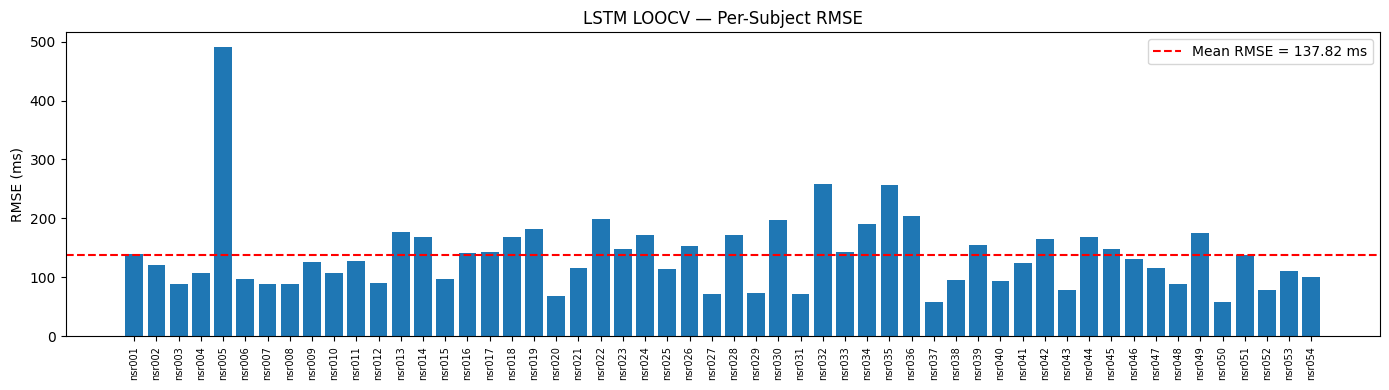

In [ ]:


# ============================================================
# CELL D — Summarize results
# ============================================================

results_df = pd.read_csv(CHECKPOINT_PATH)

mean_rmse = results_df["rmse_ms"].mean()
std_rmse  = results_df["rmse_ms"].std()

print("=" * 50)
print(f"LSTM LOOCV Results  ({len(results_df)} subjects)")
print("=" * 50)
print(f"Mean RMSE:  {mean_rmse:.2f} ms")
print(f"Std  RMSE:  {std_rmse:.2f} ms")
print()

# HRV metric comparison (mean across all subjects)
metrics = ["mean_rr", "sdnn", "rmssd", "sd1", "sd2"]
print(f"{'Metric':<12} {'Real (mean)':>14} {'Synthetic (mean)':>18} {'Abs Error':>12}")
print("-" * 60)
for m in metrics:
    real_avg = results_df[f"real_{m}"].mean()
    syn_avg  = results_df[f"syn_{m}"].mean()
    err      = abs(real_avg - syn_avg)
    print(f"{m:<12} {real_avg:>14.2f} {syn_avg:>18.2f} {err:>12.2f}")

# Per-subject RMSE plot
plt.figure(figsize=(14, 4))
plt.bar(range(len(results_df)), results_df["rmse_ms"].values)
plt.axhline(mean_rmse, color="red", linestyle="--", label=f"Mean RMSE = {mean_rmse:.2f} ms")
plt.xticks(range(len(results_df)), results_df["subject"].str.replace("_rr.txt", ""), rotation=90, fontsize=7)
plt.ylabel("RMSE (ms)")
plt.title("LSTM LOOCV — Per-Subject RMSE")
plt.legend()
plt.tight_layout()
plt.show()

# variability observing in model is greater than threshold
# find thereshold for healthy indviduals to beocming abnormal rr interval